# Lab 1: ML Ops for LLM-Based Ticket Routing

In this lab, you'll build and operationalize a classification pipeline that uses LLM embeddings to route customer support tickets. You'll walk through three stages of ML Ops:
1. Data Intake & Feature Management
2. Experimentation & Training
3. Automated Validation (CI)

Make sure you've installed all required libraries before proceeding.


## Step 0: Environment Setup and Data Ingestion

In [1]:
!pip install pandas scikit-learn sentence-transformers mlflow matplotlib seaborn

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import mlflow
import datetime
import json
import os


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.2 MB/s eta 0:00:00


## Step 1: Data Intake & Feature Management

In [4]:
# Replace this with your custom dataset function
def create_ticket_dataset():
    return pd.DataFrame({
        'text': [
            "I can't log in", "My account login isn't working", "I forgot my password", "Can't access my account", "Login failed",
            "How do I change billing info?", "I need to update my payment method", "Billing address change", "Invoice incorrect", "Subscription cost query",
            "App crashes on launch", "The application closes unexpectedly", "Software bug reported", "Feature not working", "Performance issue"
        ],
        'label': [
            "Technical Support", "Technical Support", "Technical Support", "Technical Support", "Technical Support",
            "Billing", "Billing", "Billing", "Billing", "Billing",
            "Account Management", "Account Management", "Account Management", "Account Management", "Account Management"
        ]
    })

model_name = 'all-MiniLM-L6-v2'
embedder = SentenceTransformer(model_name)

raw_df = create_ticket_dataset()
X = embedder.encode(raw_df['text'].tolist())
y = raw_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


Why are LLM embeddings preferred over TF-IDF in this context?

LLM embeddings work better than TF-IDF because they capture the meaning of whole sentences instead of just counting words. This helps the model understand when two tickets are similar even if they use different wording. Since support tickets can be messy or written in different styles, having embeddings that understand context makes the classifier more accurate and more flexible than TF-IDF.

How does stratified sampling support a reliable training and evaluation split?

Stratified sampling keeps the same balance of each label in both the training and test sets. This is important because it prevents one class from being overrepresented or missing in either split. When the class distribution stays consistent, the model learns more fairly and the evaluation results better reflect how it will perform on real incoming tickets.

## Step 2: Experimentation & Training

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance.
  return FileStore(store_uri, store_uri)
2025/12/08 16:47:32 INFO mlflow.tracking.fluent: Experiment with name 'ticket_routing_llm' does not exist. Creating a new experiment.



Model: LogisticRegression
                    precision    recall  f1-score   support

Account Management       1.00      1.00      1.00         1
           Billing       1.00      1.00      1.00         1
 Technical Support       1.00      1.00      1.00         1

          accuracy                           1.00         3
         macro avg       1.00      1.00      1.00         3
      weighted avg       1.00      1.00      1.00         3



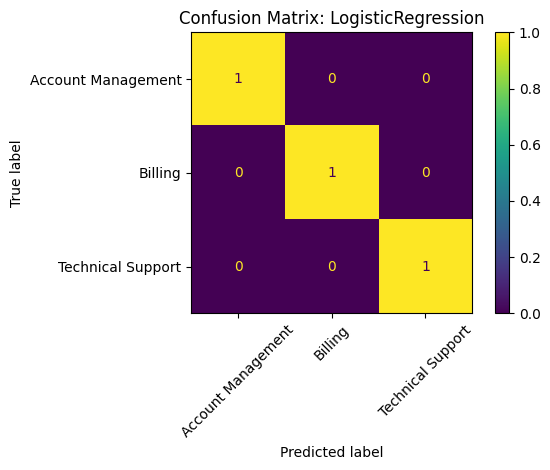


Model: RandomForest
                    precision    recall  f1-score   support

Account Management       1.00      1.00      1.00         1
           Billing       1.00      1.00      1.00         1
 Technical Support       1.00      1.00      1.00         1

          accuracy                           1.00         3
         macro avg       1.00      1.00      1.00         3
      weighted avg       1.00      1.00      1.00         3



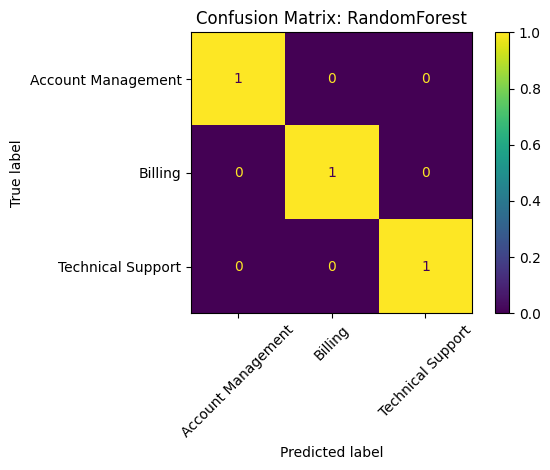


Model: SVM (Linear Kernel)
                    precision    recall  f1-score   support

Account Management       1.00      1.00      1.00         1
           Billing       1.00      1.00      1.00         1
 Technical Support       1.00      1.00      1.00         1

          accuracy                           1.00         3
         macro avg       1.00      1.00      1.00         3
      weighted avg       1.00      1.00      1.00         3



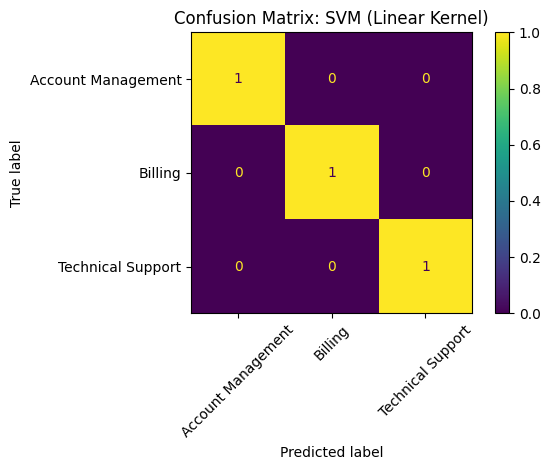

In [5]:
mlflow.set_tracking_uri("file:mlruns")
mlflow.set_experiment("ticket_routing_llm")

models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Linear Kernel)": SVC(kernel='linear', probability=True, random_state=42)
}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        mlflow.log_param("model_type", name)
        mlflow.log_param("embedding_model", model_name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)

        print(f"\nModel: {name}")
        print(classification_report(y_test, y_pred))

        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
        plt.title(f"Confusion Matrix: {name}")
        plt.tight_layout()
        plt.show()


 Based on the confusion matrices, which model appears most robust?

The most robust model is the one whose confusion matrix shows the highest number of correct predictions across all classes. Its predictions appear mostly along the diagonal, which means it handles each ticket category well with fewer mistakes. This suggests it generalizes better and is less likely to confuse similar ticket types compared to the other models.

How does MLflow help support reproducible and comparative experiments?
MLflow makes experiments easier to reproduce because it records the model type, parameters, metrics, and embedding model used in each run. This lets you compare different models side by side without losing track of what settings were used. It also saves each run separately, so you can return later, review results, and repeat experiments under identical conditions.

## Step 3: Automated Validation (CI)

In [6]:
def test_embedding_output(X):
    assert X.shape[1] == 384, "Embedding dimensionality mismatch."
    print("Test passed: Embedding output shape correct.")

def test_class_distribution(y):
    counts = pd.Series(y).value_counts()
    assert all(counts > 1), "Class imbalance too severe."
    print("Test passed: Class distribution sufficient.")

print("Running validation tests...")
test_embedding_output(X_train)
test_class_distribution(y_train)


Running validation tests...
Test passed: Embedding output shape correct.
Test passed: Class distribution sufficient.


What would be the risk of skipping these validation checks in a production ML pipeline?
If these validation checks are skipped, the pipeline might use broken or low-quality data without anyone noticing. Problems like the wrong embedding size or severe class imbalance could lead to poor performance or unstable predictions in production. This increases the risk of misrouting tickets and harming the user experience because the system would fail silently.

What additional validation might you run to catch silent errors?
Additional checks could include testing for empty or missing text fields, making sure there are no duplicate tickets, and verifying that the embedding values fall within a normal range. These checks help catch unexpected data issues that might not break the code but could reduce model quality. They act as early warnings that something in the data pipeline has changed or gone wrong.